# Chapter 3: Moving from pandas to Polars

In [1]:
import polars as pl
pl.__version__  # The book is built with Polars version 1.20.0

'1.33.0'

## 3.1 Animals

In [2]:
%lsmagic

Available line magics:
%alias  %alias_magic  %autoawait  %autocall  %automagic  %autosave  %bookmark  %cd  %clear  %cls  %code_wrap  %colors  %conda  %config  %connect_info  %copy  %ddir  %debug  %dhist  %dirs  %doctest_mode  %echo  %ed  %edit  %env  %gui  %hist  %history  %killbgscripts  %ldir  %less  %load  %load_ext  %loadpy  %logoff  %logon  %logstart  %logstate  %logstop  %ls  %lsmagic  %macro  %magic  %mamba  %matplotlib  %micromamba  %mkdir  %more  %notebook  %page  %pastebin  %pdb  %pdef  %pdoc  %pfile  %pinfo  %pinfo2  %pip  %popd  %pprint  %precision  %prun  %psearch  %psource  %pushd  %pwd  %pycat  %pylab  %qtconsole  %quickref  %recall  %rehashx  %reload_ext  %ren  %rep  %rerun  %reset  %reset_selective  %rmdir  %run  %save  %sc  %set_env  %store  %subshell  %sx  %system  %tb  %time  %timeit  %unalias  %unload_ext  %uv  %who  %who_ls  %whos  %xdel  %xmode

Available cell magics:
%%!  %%HTML  %%SVG  %%bash  %%capture  %%cmd  %%code_wrap  %%debug  %%file  %%html  %%javascript

In [ ]:
!type data\animals.csv

animal,class,habitat,diet,lifespan,status,features,weight
dolphin,mammal,oceans/rivers,carnivore,40,least concern,high intelligence,150
duck,bird,wetlands,omnivore,8,least concern,waterproof feathers,3
elephant,mammal,savannah,herbivore,60,endangered,large ears and trunk,8000
ibis,bird,wetlands,omnivore,16,least concern,"long, curved bill",1
impala,mammal,savannah,herbivore,12,least concern,"long, curved horns",70
kudu,mammal,savannah,herbivore,15,least concern,spiral horns,250
narwhal,mammal,arctic ocean,carnivore,40,near threatened,"long, spiral tusk",
panda,mammal,forests,herbivore,20,vulnerable,black and white coloration,100
polar bear,mammal,arctic,carnivore,25,vulnerable,thick fur and blubber,720
ray,fish,oceans,carnivore,20,"","flat, disc-shaped body",90


## 3.2 Similarities to Recognize

## 3.3 Appearances to Appreciate

In [4]:
import pandas as pd
import polars as pl

### 3.3.1 Differences in Code

In [5]:
animals_pd = pd.read_csv("data/animals.csv", sep=",", header=0)
animals_pl = pl.read_csv("data/animals.csv", separator=",", has_header=True)

print(f"{type(animals_pd) = }")
print(f"{type(animals_pl) = }")

type(animals_pd) = <class 'pandas.DataFrame'>
type(animals_pl) = <class 'polars.dataframe.frame.DataFrame'>


### 3.3.2 Differences in Display

In [6]:
animals_pd

,animal,class,habitat,diet,lifespan,status,features,weight
0,dolphin,mammal,oceans/rivers,carnivore,40,least concern,high intelligence,150.0
1,duck,bird,wetlands,omnivore,8,least concern,waterproof feathers,3.0
2,elephant,mammal,savannah,herbivore,60,endangered,large ears and trunk,8000.0
3,ibis,bird,wetlands,omnivore,16,least concern,"long, curved bill",1.0
4,impala,mammal,savannah,herbivore,12,least concern,"long, curved horns",70.0
5,kudu,mammal,savannah,herbivore,15,least concern,spiral horns,250.0
6,narwhal,mammal,arctic ocean,carnivore,40,near threatened,"long, spiral tusk",NaN
7,panda,mammal,forests,herbivore,20,vulnerable,black and white coloration,100.0
8,polar bear,mammal,arctic,carnivore,25,vulnerable,thick fur and blubber,720.0
9,ray,fish,oceans,carnivore,20,NaN,"flat, disc-shaped body",90.0


In [7]:
animals_pl

animal,class,habitat,diet,lifespan,status,features,weight
str,str,str,str,i64,str,str,i64
"""dolphin""","""mammal""","""oceans/rivers""","""carnivore""",40,"""least concern""","""high intelligence""",150
"""duck""","""bird""","""wetlands""","""omnivore""",8,"""least concern""","""waterproof feathers""",3
"""elephant""","""mammal""","""savannah""","""herbivore""",60,"""endangered""","""large ears and trunk""",8000
"""ibis""","""bird""","""wetlands""","""omnivore""",16,"""least concern""","""long, curved bill""",1
"""impala""","""mammal""","""savannah""","""herbivore""",12,"""least concern""","""long, curved horns""",70
"""kudu""","""mammal""","""savannah""","""herbivore""",15,"""least concern""","""spiral horns""",250
"""narwhal""","""mammal""","""arctic ocean""","""carnivore""",40,"""near threatened""","""long, spiral tusk""",null
"""panda""","""mammal""","""forests""","""herbivore""",20,"""vulnerable""","""black and white coloration""",100
"""polar bear""","""mammal""","""arctic""","""carnivore""",25,"""vulnerable""","""thick fur and blubber""",720


In [8]:
animals_pd["animal"]

0       dolphin
1          duck
2      elephant
3          ibis
4        impala
5          kudu
6       narwhal
7         panda
8    polar bear
9           ray
Name: animal, dtype: str

In [9]:
animals_pl.get_column("animal")

animal
str
"""dolphin"""
"""duck"""
"""elephant"""
"""ibis"""
"""impala"""
"""kudu"""
"""narwhal"""
"""panda"""
"""polar bear"""


In [10]:
animals_pd = animals_pd.drop(columns=["habitat", "diet", "features"])
animals_pd

,animal,class,lifespan,status,weight
0,dolphin,mammal,40,least concern,150.0
1,duck,bird,8,least concern,3.0
2,elephant,mammal,60,endangered,8000.0
3,ibis,bird,16,least concern,1.0
4,impala,mammal,12,least concern,70.0
5,kudu,mammal,15,least concern,250.0
6,narwhal,mammal,40,near threatened,NaN
7,panda,mammal,20,vulnerable,100.0
8,polar bear,mammal,25,vulnerable,720.0
9,ray,fish,20,NaN,90.0


In [11]:
animals_pl = animals_pl.drop("habitat", "diet", "features")
animals_pl

animal,class,lifespan,status,weight
str,str,i64,str,i64
"""dolphin""","""mammal""",40,"""least concern""",150
"""duck""","""bird""",8,"""least concern""",3
"""elephant""","""mammal""",60,"""endangered""",8000
"""ibis""","""bird""",16,"""least concern""",1
"""impala""","""mammal""",12,"""least concern""",70
"""kudu""","""mammal""",15,"""least concern""",250
"""narwhal""","""mammal""",40,"""near threatened""",null
"""panda""","""mammal""",20,"""vulnerable""",100
"""polar bear""","""mammal""",25,"""vulnerable""",720


## 3.4 Concepts to Unlearn

### 3.4.1 Index

pandas df always has index, usually RangeIndex.<br>
Aggregate may change the index structure, like index of a tuple, MultiIndex

In [12]:
animals_pd.index

RangeIndex(start=0, stop=10, step=1)

In [13]:
animals_agg_pd = animals_pd.groupby(["class", "status"])[["weight"]].mean()
animals_agg_pd

weight
class  status                      
bird   least concern       2.000000
mammal endangered       8000.000000
       least concern     156.666667
       near threatened          NaN
       vulnerable        410.000000

In [14]:
animals_agg_pd.index

MultiIndex([(  'bird',   'least concern'),
            ('mammal',      'endangered'),
            ('mammal',   'least concern'),
            ('mammal', 'near threatened'),
            ('mammal',      'vulnerable')],
           names=['class', 'status'])

In [15]:
animals_agg_pd.reset_index()

,class,status,weight
0,bird,least concern,2.000000
1,mammal,endangered,8000.000000
2,mammal,least concern,156.666667
3,mammal,near threatened,NaN
4,mammal,vulnerable,410.000000


Polars df removed indexing.

In [16]:
animals_pl.group_by(["class", "status"]).agg(pl.col("weight").mean())

class,status,weight
str,str,f64
"""mammal""","""near threatened""",null
"""fish""","""""",90.0
"""mammal""","""least concern""",156.666667
"""mammal""","""endangered""",8000.0
"""mammal""","""vulnerable""",410.0
"""bird""","""least concern""",2.0


### 3.4.2 Axes

pandas df has axis=0 -> row, and axis=1 -> col. Many func default axis=0 work on rows.

In [17]:
# This raises a KeyError:
# animals_pd.drop("weight")

In [18]:
animals_pd.drop("weight", axis=1)
# animals_pd.drop(columns=["weight"])

,animal,class,lifespan,status
0,dolphin,mammal,40,least concern
1,duck,bird,8,least concern
2,elephant,mammal,60,endangered
3,ibis,bird,16,least concern
4,impala,mammal,12,least concern
5,kudu,mammal,15,least concern
6,narwhal,mammal,40,near threatened
7,panda,mammal,20,vulnerable
8,polar bear,mammal,25,vulnerable
9,ray,fish,20,NaN


### 3.4.3 Indexing and Slicing

In [19]:
animals_pd[["animal", "class"]]

,animal,class
0,dolphin,mammal
1,duck,bird
2,elephant,mammal
3,ibis,bird
4,impala,mammal
5,kudu,mammal
6,narwhal,mammal
7,panda,mammal
8,polar bear,mammal
9,ray,fish


In [20]:
animals_pd[animals_pd["status"] == "endangered"]

,animal,class,lifespan,status,weight
2,elephant,mammal,60,endangered,8000.0


In [21]:
animals_pd[:3]

,animal,class,lifespan,status,weight
0,dolphin,mammal,40,least concern,150.0
1,duck,bird,8,least concern,3.0
2,elephant,mammal,60,endangered,8000.0


In [22]:
animals_pd["weight"] = animals_pd["weight"] * 1000

pandas col re-evaluation (sort, math...) will align index with it<br>
thus showing sorted col will still align with index, looks like unchanged.

In [23]:
animals_pd["weight"]

0     150000.0
1       3000.0
2    8000000.0
3       1000.0
4      70000.0
5     250000.0
6          NaN
7     100000.0
8     720000.0
9      90000.0
Name: weight, dtype: float64

In [24]:
animals_pd["weight"] = animals_pd["weight"].sort_values()

In [25]:
animals_pd["weight"]

0     150000.0
1       3000.0
2    8000000.0
3       1000.0
4      70000.0
5     250000.0
6          NaN
7     100000.0
8     720000.0
9      90000.0
Name: weight, dtype: float64

### 3.4.4 Eagerness

pandas execute op eagerly. Many op are in-place.<br>
Polars can be lazy, default not in-place

In [26]:
lazy_query = (
    pl.scan_csv("data/animals.csv")
    .group_by("class")
    .agg(pl.col("weight").mean())
    .filter(pl.col("class") == "mammal")
)

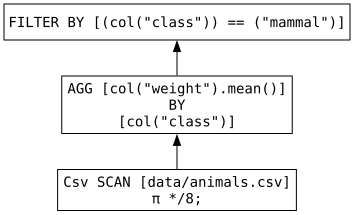

In [27]:
lazy_query.show_graph(optimized=False)
# lazy_query.explain()

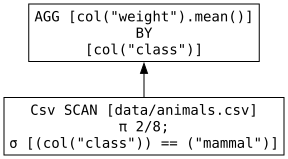

In [28]:
lazy_query.show_graph()

In [29]:
lazy_query.collect()

class,weight
str,f64
"""mammal""",1548.333333


### 3.4.5 Relaxedness

Polars is more strict than pandas:

1. Date: python datetime, Date, Datetime type
2. Col name: string
3. Null: null (data lost), NaN (illegal, not a number)
4. Type convert: all type can null
5. Aggregate: keep all groups
6. Type infer: no type revert
7. Bool: bool only compare with bool
8. Col name uniqueness
9. Return type: Return df
10. Agg output: single rolw df

## 3.5 Syntax to Forget

### 3.5.1 Common Operations Side By Side

#### 1. Removing duplicate values

In [30]:
animals_pd.drop_duplicates(subset="class")

,animal,class,lifespan,status,weight
0,dolphin,mammal,40,least concern,150000.0
1,duck,bird,8,least concern,3000.0
9,ray,fish,20,NaN,90000.0


Polars use concurrent query, thus the order of result is not stable.<br>
To keep original order, maintain_order=True

In [31]:
animals_pl.unique(subset="class")

animal,class,lifespan,status,weight
str,str,i64,str,i64
"""ray""","""fish""",20,"""""",90
"""dolphin""","""mammal""",40,"""least concern""",150
"""duck""","""bird""",8,"""least concern""",3


#### 2. Removing missing values

In [32]:
animals_pd.dropna(subset="weight")

,animal,class,lifespan,status,weight
0,dolphin,mammal,40,least concern,150000.0
1,duck,bird,8,least concern,3000.0
2,elephant,mammal,60,endangered,8000000.0
3,ibis,bird,16,least concern,1000.0
4,impala,mammal,12,least concern,70000.0
5,kudu,mammal,15,least concern,250000.0
7,panda,mammal,20,vulnerable,100000.0
8,polar bear,mammal,25,vulnerable,720000.0
9,ray,fish,20,NaN,90000.0


In [33]:
animals_pl.drop_nulls(subset="weight")

animal,class,lifespan,status,weight
str,str,i64,str,i64
"""dolphin""","""mammal""",40,"""least concern""",150
"""duck""","""bird""",8,"""least concern""",3
"""elephant""","""mammal""",60,"""endangered""",8000
"""ibis""","""bird""",16,"""least concern""",1
"""impala""","""mammal""",12,"""least concern""",70
"""kudu""","""mammal""",15,"""least concern""",250
"""panda""","""mammal""",20,"""vulnerable""",100
"""polar bear""","""mammal""",25,"""vulnerable""",720
"""ray""","""fish""",20,"""""",90


#### 3. Sorting rows

In [34]:
animals_pd.sort_values("weight", ascending=False)

,animal,class,lifespan,status,weight
2,elephant,mammal,60,endangered,8000000.0
8,polar bear,mammal,25,vulnerable,720000.0
5,kudu,mammal,15,least concern,250000.0
0,dolphin,mammal,40,least concern,150000.0
7,panda,mammal,20,vulnerable,100000.0
9,ray,fish,20,NaN,90000.0
4,impala,mammal,12,least concern,70000.0
1,duck,bird,8,least concern,3000.0
3,ibis,bird,16,least concern,1000.0
6,narwhal,mammal,40,near threatened,NaN


Polars sorting, null value default first, or nulls_last=True

In [35]:
animals_pl.sort("weight", descending=True)

animal,class,lifespan,status,weight
str,str,i64,str,i64
"""narwhal""","""mammal""",40,"""near threatened""",null
"""elephant""","""mammal""",60,"""endangered""",8000
"""polar bear""","""mammal""",25,"""vulnerable""",720
"""kudu""","""mammal""",15,"""least concern""",250
"""dolphin""","""mammal""",40,"""least concern""",150
"""panda""","""mammal""",20,"""vulnerable""",100
"""ray""","""fish""",20,"""""",90
"""impala""","""mammal""",12,"""least concern""",70
"""duck""","""bird""",8,"""least concern""",3


#### 4. Casting an existing column

In [36]:
animals_pd.assign(lifespan=animals_pd["lifespan"].astype(float))

,animal,class,lifespan,status,weight
0,dolphin,mammal,40.0,least concern,150000.0
1,duck,bird,8.0,least concern,3000.0
2,elephant,mammal,60.0,endangered,8000000.0
3,ibis,bird,16.0,least concern,1000.0
4,impala,mammal,12.0,least concern,70000.0
5,kudu,mammal,15.0,least concern,250000.0
6,narwhal,mammal,40.0,near threatened,NaN
7,panda,mammal,20.0,vulnerable,100000.0
8,polar bear,mammal,25.0,vulnerable,720000.0
9,ray,fish,20.0,NaN,90000.0


In [37]:
animals_pl.with_columns(pl.col("lifespan").cast(pl.Float64))

animal,class,lifespan,status,weight
str,str,f64,str,i64
"""dolphin""","""mammal""",40.0,"""least concern""",150
"""duck""","""bird""",8.0,"""least concern""",3
"""elephant""","""mammal""",60.0,"""endangered""",8000
"""ibis""","""bird""",16.0,"""least concern""",1
"""impala""","""mammal""",12.0,"""least concern""",70
"""kudu""","""mammal""",15.0,"""least concern""",250
"""narwhal""","""mammal""",40.0,"""near threatened""",null
"""panda""","""mammal""",20.0,"""vulnerable""",100
"""polar bear""","""mammal""",25.0,"""vulnerable""",720


#### 5. Aggregating rows

In [38]:
animals_pd.groupby(["class", "status"])[["weight"]].mean()

weight
class  status                       
bird   least concern    2.000000e+03
mammal endangered       8.000000e+06
       least concern    1.566667e+05
       near threatened           NaN
       vulnerable       4.100000e+05

In [39]:
animals_pl.group_by("class", "status").agg(pl.col("weight").mean())

class,status,weight
str,str,f64
"""mammal""","""vulnerable""",410.0
"""mammal""","""endangered""",8000.0
"""mammal""","""near threatened""",null
"""fish""","""""",90.0
"""mammal""","""least concern""",156.666667
"""bird""","""least concern""",2.0


## 3.6 To and From pandas

In [40]:
animals_pl = pl.DataFrame(animals_pd)

animals_pl

animal,class,lifespan,status,weight
str,str,i64,str,f64
"""dolphin""","""mammal""",40,"""least concern""",150000.0
"""duck""","""bird""",8,"""least concern""",3000.0
"""elephant""","""mammal""",60,"""endangered""",8e6
"""ibis""","""bird""",16,"""least concern""",1000.0
"""impala""","""mammal""",12,"""least concern""",70000.0
"""kudu""","""mammal""",15,"""least concern""",250000.0
"""narwhal""","""mammal""",40,"""near threatened""",null
"""panda""","""mammal""",20,"""vulnerable""",100000.0
"""polar bear""","""mammal""",25,"""vulnerable""",720000.0


In [41]:
there_and_back_again_df = animals_pl.to_pandas()

there_and_back_again_df

,animal,class,lifespan,status,weight
0,dolphin,mammal,40,least concern,150000.0
1,duck,bird,8,least concern,3000.0
2,elephant,mammal,60,endangered,8000000.0
3,ibis,bird,16,least concern,1000.0
4,impala,mammal,12,least concern,70000.0
5,kudu,mammal,15,least concern,250000.0
6,narwhal,mammal,40,near threatened,NaN
7,panda,mammal,20,vulnerable,100000.0
8,polar bear,mammal,25,vulnerable,720000.0
9,ray,fish,20,NaN,90000.0


## Takeaways